In [1]:
import numpy as np
from scipy.optimize import bisect
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigs

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
beta = 0.01
# phic = (3 * beta)**(-0.5)
# M = phic / 2**0.5
Lambda = (1e-15)**0.25
nWaterfall = 1
psic = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5

def infPotFunc(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * ((1 - (psi / M)**2)**2 + 2 * (phi * psi / phic / M)**2 + beta * (phi - phic)**3))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * phi * (psi / phic / M)**2 + 3 * beta * (phi - phic)**2))
    
def infPotDerivFunc_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 * psi / M**2 * (1 - (psi / M)**2) + 4 * psi * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * (psi / phic / M)**2 + 6 * beta * (phi - phic)))

def infPotDeriv2Func_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psi / M / M)**2 + 4 * (phi / phic / M)**2))

def infPotDeriv2Func_phipsi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (8 * phi * psi / (phic * M)**2))

def eta_psi(Phi):
    return infPotDeriv2Func_psi(Phi) / infPotFunc(Phi)

def etaCl_phi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_phi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_phi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)

def etaCl_psi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_psi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_psi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psi]
infPotentialDeriv2Funcs = [[infPotDeriv2Func_phi, infPotDeriv2Func_phipsi], [infPotDeriv2Func_phipsi, infPotDeriv2Func_psi]]

nGrid = 100

In [3]:
deltaPhiWell = 2 * (2 / 3 * Lambda**4 / beta) ** (1 / 3)
phiLargeEtaMax = bisect(lambda phi: etaCl_phi([phi, 0]) - 0.1, phic + 0.01 * deltaPhiWell, phic + 10 * deltaPhiWell) 
phiLargeEtaMin = phic - (phiLargeEtaMax - phic)

# 以下は1912.05399に準拠。下限はad hoc
phimax = phic + beta**(-1/3)
phimin = phic - beta**(-1/3)

In [4]:
psiLargeEtaMax = bisect(lambda psi: etaCl_psi([phiLargeEtaMax, psi]) - 0.1, 0.0001 * psic, 1000 * psic)
psiLargeEtaMin = -psiLargeEtaMax 

psimax = bisect(lambda psi: eta_psi([phic, psi]) - 1, 0, M)
psimin = -psimax

In [5]:
customGrid_phi = np.concatenate([phic - np.exp(np.linspace(np.log(phic - phimin), np.log(phic - phiLargeEtaMin), nGrid // 4, endpoint=False)),
                                 np.linspace(phiLargeEtaMin, phiLargeEtaMax, nGrid // 2),
                                 phic + np.exp(np.linspace(np.log(phiLargeEtaMax - phic), np.log(phimax - phic), nGrid // 4 + 1)[1:])])
customGrid_psi = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psiLargeEtaMax), nGrid // 4 + 1))[:-1],
                                 np.linspace(psiLargeEtaMin, psiLargeEtaMax, nGrid // 2),
                                 np.exp(np.linspace(np.log(psiLargeEtaMax), np.log(psimax), nGrid // 4 + 1))[1:]])

In [46]:
phic

0.0011582420658256308

In [45]:
customGrid_phi

array([-4.64043059e+00, -2.79133398e+00, -1.67887269e+00, -1.00958904e+00,
       -6.06931794e-01, -3.64683446e-01, -2.18940975e-01, -1.31258776e-01,
       -7.85070419e-02, -4.67703215e-02, -2.76767422e-02, -1.61895826e-02,
       -9.27862926e-03, -5.12083241e-03, -2.61940116e-03, -1.11447956e-03,
       -2.09082291e-04,  3.35626629e-04,  6.63336702e-04,  8.60495017e-04,
        9.79110232e-04,  1.05047202e-03,  1.09340500e-03,  1.11923451e-03,
        1.13477418e-03,  1.14412322e-03,  1.14469950e-03,  1.14527578e-03,
        1.14585206e-03,  1.14642833e-03,  1.14700461e-03,  1.14758089e-03,
        1.14815717e-03,  1.14873345e-03,  1.14930973e-03,  1.14988601e-03,
        1.15046229e-03,  1.15103857e-03,  1.15161485e-03,  1.15219113e-03,
        1.15276741e-03,  1.15334369e-03,  1.15391997e-03,  1.15449625e-03,
        1.15507253e-03,  1.15564881e-03,  1.15622509e-03,  1.15680137e-03,
        1.15737765e-03,  1.15795393e-03,  1.15853021e-03,  1.15910649e-03,
        1.15968276e-03,  

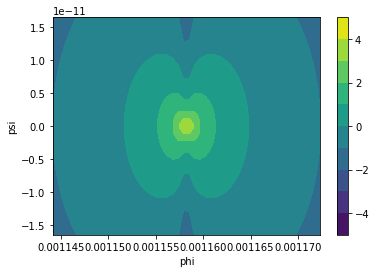

In [6]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_phi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

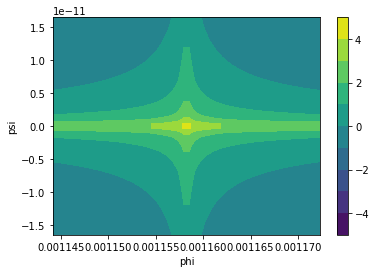

In [7]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_psi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

In [8]:
fpFinDiff_NeuDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Neumann0OriFunc", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# # ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
# customGrid_phi_woEnd = customGrid_phi[1:-1]
# customGrid_psi_woEnd = customGrid_psi[1:-1]
# vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
# maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psi_woEnd)), False)
# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
#             maskMat[i1, i2] = True
#             fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuDir, eigVecs_NeuDir = eigs(fpFinDiff_NeuDir, 10, sigma=0, which='LM')
eigVecsSort_NeuDir = eigVecs_NeuDir.T[np.argsort(np.abs(eigVals_NeuDir))]
eigValsSort_NeuDir = eigVals_NeuDir[np.argsort(np.abs(eigVals_NeuDir))]

In [9]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_NeuDir)
np.set_printoptions()

[[9.743363288256524e+29 -1.296307270735323e-03 0.000000000000000e+00 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [-2.869917696182511e-03 7.458697391272851e+29 -3.707702112869963e-03 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [0.000000000000000e+00 -5.394242950986140e-03 4.561817635173609e+29 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 ...
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  1.323896088597793e+29 -8.059293381373140e-03 0.000000000000000e+00]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  -5.539509319448316e-03 2.355916391055893e+29 -4.129533681096293e-03]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  0.000000000000000e+00 -2.707250532978950e-03 3.559574168285675e+29]]


<ipython-input-10-e4c02b133dbc>:2: RuntimeWarning: divide by zero encountered in log10
  cntr1 = ax1.contourf(np.arange((nGrid-2)**2), np.arange((nGrid-2)**2), np.log10(np.abs(fpFinDiff_NeuDir)))


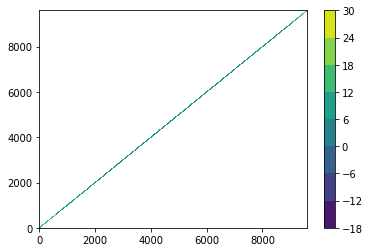

In [10]:
fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(np.arange((nGrid-2)**2), np.arange((nGrid-2)**2), np.log10(np.abs(fpFinDiff_NeuDir)))
fig.colorbar(cntr1, ax=ax1)
plt.show()

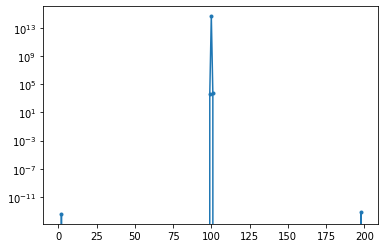

In [11]:
ax = plt.gca()
plt.plot(np.abs(fpFinDiff_NeuDir[1000,900:1100]), marker=".")
ax.set_yscale("log")
plt.show()

In [12]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = eigs(fpFinDiff_DirDir, 10, sigma=0, which='LM')
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(np.abs(eigVals_DirDir))]
eigValsSort_DirDir = eigVals_DirDir[np.argsort(np.abs(eigVals_DirDir))]

In [13]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_DirDir)
np.set_printoptions()

[[9.743363288256524e+29 -1.296307270735323e-03 0.000000000000000e+00 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [-2.869917696182511e-03 7.458697391272851e+29 -3.707702112869963e-03 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [0.000000000000000e+00 -5.394242950986140e-03 4.561817635173609e+29 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 ...
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  1.323896088597793e+29 -8.059293381373140e-03 0.000000000000000e+00]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  -5.539509319448316e-03 2.355916391055893e+29 -4.129533681096293e-03]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  0.000000000000000e+00 -2.707250532978950e-03 3.559574168285675e+29]]


c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


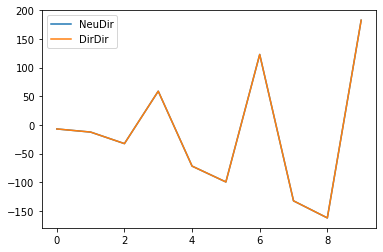

In [14]:
ax = plt.gca()
plt.plot(eigValsSort_NeuDir, label = "NeuDir")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

In [15]:
np.set_printoptions(formatter={'float': '{:.30e}'.format})
print(eigValsSort_NeuDir[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[  -7.03865612+0.j  -12.49705878+0.j  -32.64856266+0.j   58.9201442 +0.j
  -71.93230036+0.j  -99.60808939+0.j  123.04545902+0.j -132.60411876+0.j
 -162.40563529+0.j  182.79735358+0.j]
[  -7.03865612+0.j  -12.49705878+0.j  -32.64856266+0.j   58.9201442 +0.j
  -71.93230036+0.j  -99.60808939+0.j  123.04545902+0.j -132.60411876+0.j
 -162.40563529+0.j  182.79735358+0.j]


c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


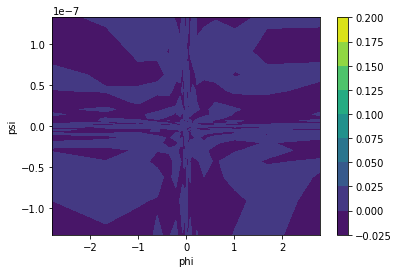

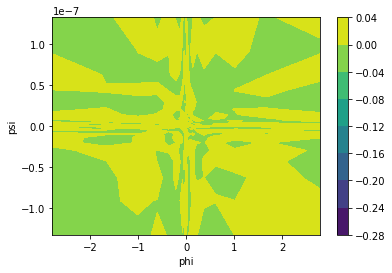

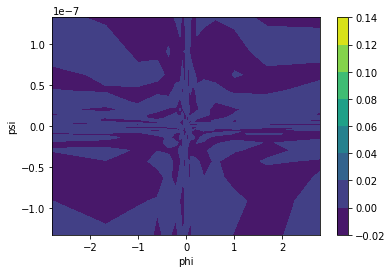

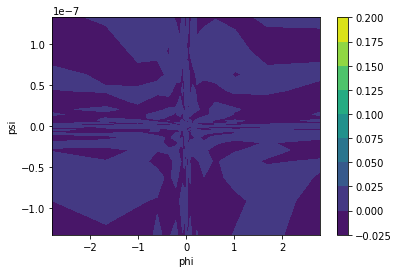

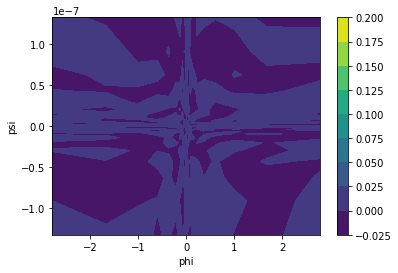

In [16]:
# 固有関数のプロット
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psi_woEnd = customGrid_psi[1:-1]

for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    plt.show()

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


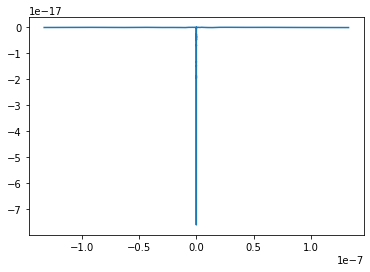

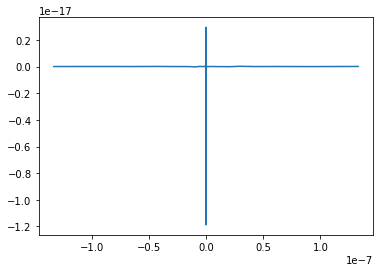

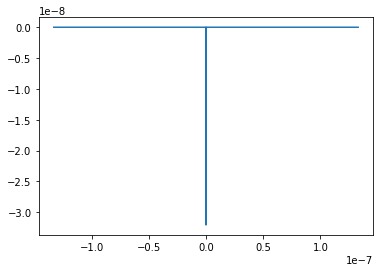

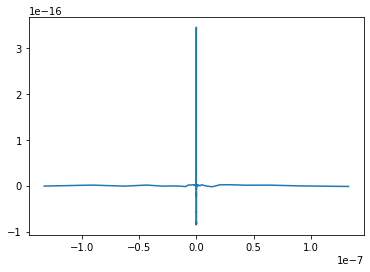

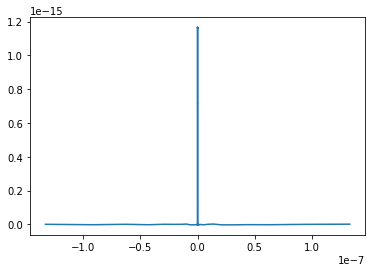

In [29]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[nGrid // 2,:])
    plt.show()

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


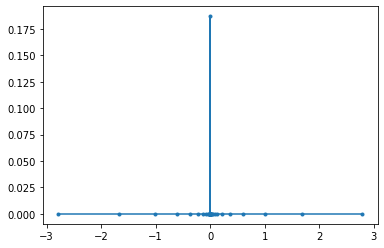

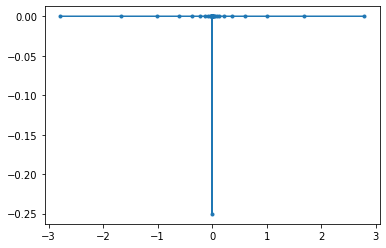

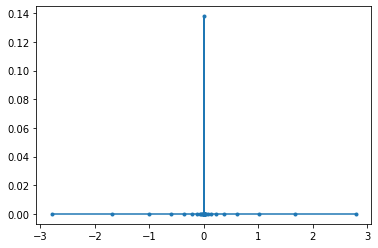

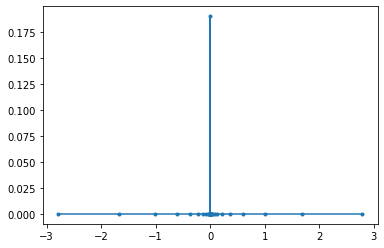

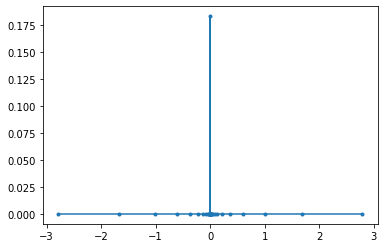

In [30]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    #ax.set_xlim(phiLargeEtaMin,phiLargeEtaMax)
    plt.show()

5928 60 (0.18766669000486352+0j)


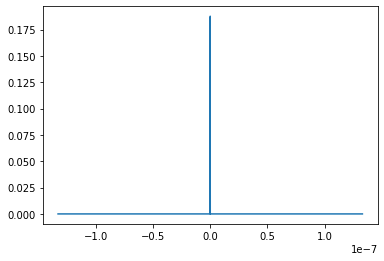

In [19]:
i = np.argmax(np.abs(eigVecsSort_NeuDir[0]))
print(i, i // (nGrid-2), eigVecsSort_NeuDir[0][i])

ax = plt.gca()
plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[0], (nGrid-2, nGrid-2))[i // (nGrid-2),:])
# ax.set_xlim(psiLargeEtaMin,psiLargeEtaMax)
plt.show()

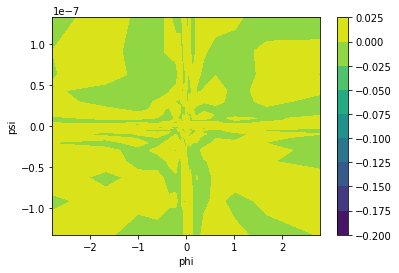

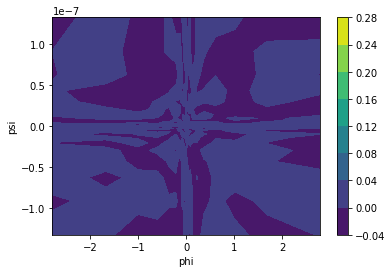

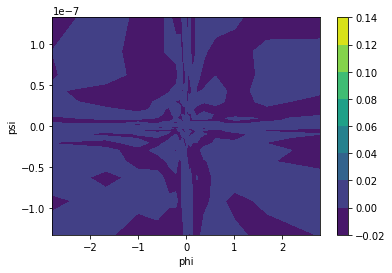

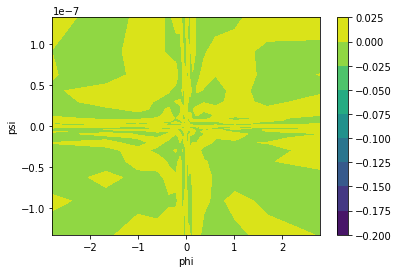

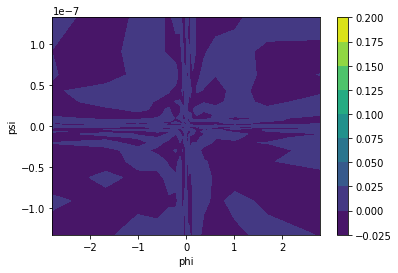

In [20]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    plt.show()

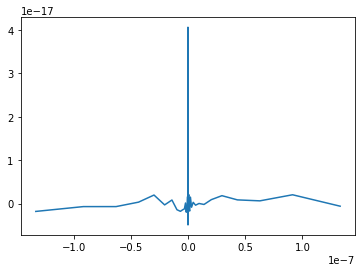

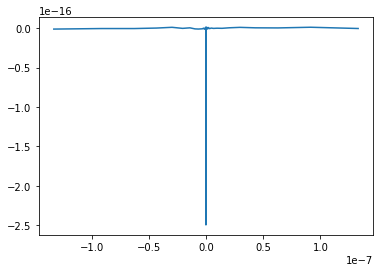

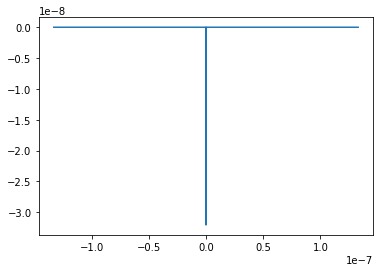

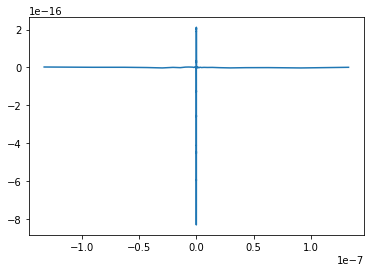

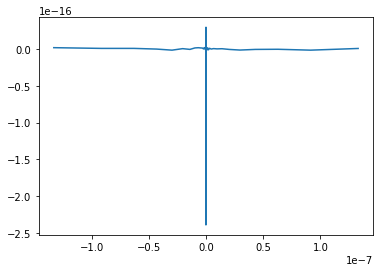

In [32]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[nGrid//2,:])
    plt.show()

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


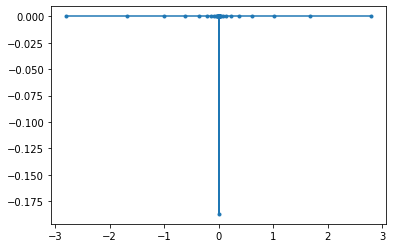

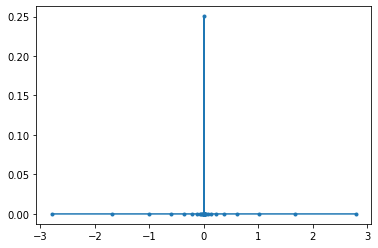

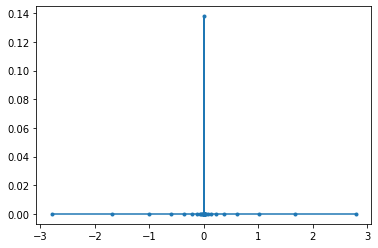

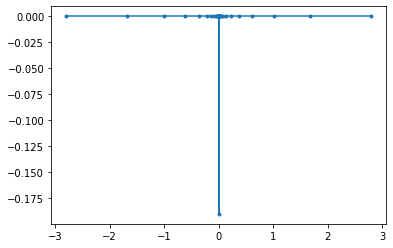

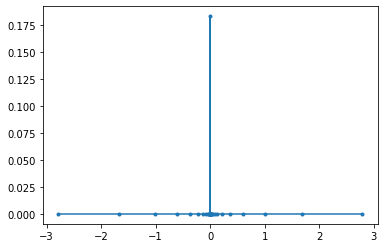

In [31]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    plt.show()

5928 60 (-0.18766669000486255+0j)


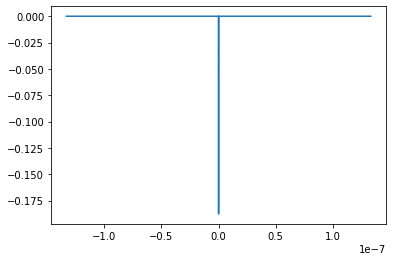

In [23]:
i = np.argmax(np.abs(eigVecsSort_DirDir[0]))
print(i, i // (nGrid-2), eigVecsSort_DirDir[0][i])

ax = plt.gca()
plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[0], (nGrid-2, nGrid-2))[i // (nGrid-2),:])
# ax.set_xlim(psiLargeEtaMin,psiLargeEtaMax)
plt.show()

In [34]:
phi_MaxAmp = customGrid_phi_woEnd[i // (nGrid-2)]
print(phi_MaxAmp)

0.0011648692807150784


In [40]:
# 局在した場所でスライスして1次元の問題として解く
infPotFunc_phiLoc = lambda psi: infPotFunc([phic, psi])
infPotDerivFunc_psi_phiLoc = lambda psi: infPotDerivFunc_psi([phic, psi])
infPotDeriv2Func_psi_phiLoc = lambda psi: infPotDeriv2Func_psi([phic, psi])

In [41]:
customGrid_psi_fine = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psiLargeEtaMax), 1001))[:-1],
                                      np.linspace(psiLargeEtaMin, psiLargeEtaMax, 2000),
                                      np.exp(np.linspace(np.log(psiLargeEtaMax), np.log(psimax), 1001))[1:]])

fpFinDiff_phiLoc = InfAdjFPFiniteDiff(
    1,
    infPotFunc_phiLoc,
    [infPotDerivFunc_psi_phiLoc],
    [infPotDeriv2Func_psi_phiLoc],
    [nGrid],
    [psimax],
    [psimin],
    ["Dirichlet"],
    ["Dirichlet"],
    customGrid=[customGrid_psi_fine],
    set0OutOfInfRegion=False
)

eigVals_phiLoc, eigVecs_phiLoc = np.linalg.eig(fpFinDiff_phiLoc)
eigVecsSort_phiLoc = eigVecs_phiLoc.T[np.argsort(eigVals_phiLoc)]
eigValsSort_phiLoc = np.sort(eigVals_phiLoc)

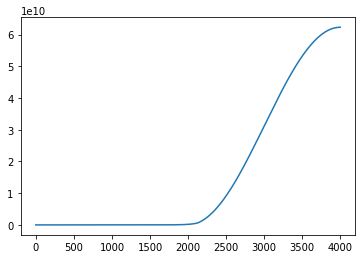

In [42]:
ax = plt.gca()
plt.plot(eigValsSort_phiLoc)
plt.show()

In [43]:
eigValsSort_phiLoc[:20]

array([5.29231848e-05, 8.38379737e-03, 2.71625945e-02, 5.05974429e-02,
       7.81937849e-02, 1.09385965e-01, 1.43918542e-01, 1.81426353e-01,
       2.21649443e-01, 2.64608913e-01, 3.10048070e-01, 3.57589965e-01,
       4.07432355e-01, 4.59412287e-01, 5.13336286e-01, 5.69347161e-01,
       6.27111784e-01, 6.86814431e-01, 7.48214218e-01, 8.11336475e-01])

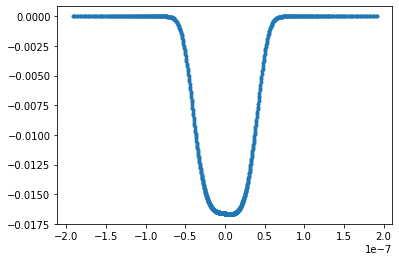

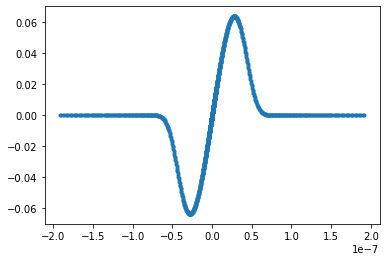

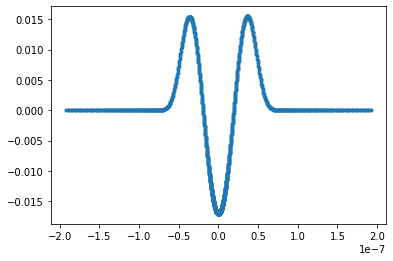

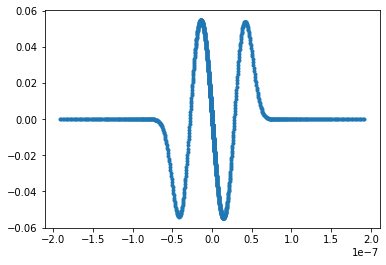

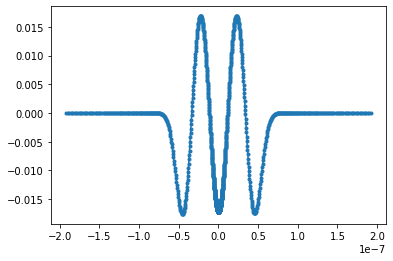

In [44]:
ax = plt.gca()

for iEig in range(5):
    plt.plot(customGrid_psi_fine[1:-1], eigVecsSort_phiLoc[iEig], marker='.')
    plt.show()

In [50]:
iMid = (nGrid - 2) * ((nGrid - 2) // 2)

In [56]:
phiMid = customGrid_phi_woEnd[iMid//(nGrid - 2)]

In [51]:
fpFinDiff_DirDir[(iMid-1):(iMid+5),(iMid-1):(iMid+5)]

array([[ 9.72324047e+09,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  9.73028253e+09, -1.36531211e-03,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -2.88990309e-03,  4.47393095e+09,
        -4.20444763e-03,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00, -6.11694557e-03,
         2.08620479e+09, -8.89939092e-03,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -1.29475010e-02,  9.79479424e+08, -1.88369949e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -2.74054722e-02,  4.61378178e+08]])

In [52]:
fpFinDiff_phiLoc_part = fpFinDiff_DirDir[iMid:(iMid+nGrid-2),iMid:(iMid+nGrid-2)]

eigVals_phiLoc_part, eigVecs_phiLoc_part = np.linalg.eig(fpFinDiff_phiLoc_part)
eigVecsSort_phiLoc_part = eigVecs_phiLoc_part.T[np.argsort(eigVals_phiLoc_part)]
eigValsSort_phiLoc_part = np.sort(eigVals_phiLoc_part)

In [53]:
eigValsSort_phiLoc_part[:20]

array([-3.26485627e+01,  2.84597136e+03,  5.63403057e+03,  8.23737060e+03,
        1.07539511e+04,  1.34415976e+04,  1.43048438e+04,  1.52910589e+04,
        2.01558211e+04,  2.65963437e+04,  2.65963994e+04,  2.86104704e+04,
        4.17064317e+04,  5.59617602e+04,  5.59617602e+04,  6.01206409e+04,
        8.98195289e+04,  1.19205017e+05,  1.19205017e+05,  1.29607165e+05])

In [58]:
# 局在した場所でスライスして1次元の問題として解く
infPotFunc_phiLocMid = lambda psi: infPotFunc([phiMid, psi])
infPotDerivFunc_psi_phiLocMid = lambda psi: infPotDerivFunc_psi([phiMid, psi])
infPotDeriv2Func_psi_phiLocMid = lambda psi: infPotDeriv2Func_psi([phiMid, psi])

fpFinDiff_phiLocMid = InfAdjFPFiniteDiff(
    1,
    infPotFunc_phiLocMid,
    [infPotDerivFunc_psi_phiLocMid],
    [infPotDeriv2Func_psi_phiLocMid],
    [nGrid],
    [psimax],
    [psimin],
    ["Dirichlet"],
    ["Dirichlet"],
    customGrid=[customGrid_psi_fine],
    set0OutOfInfRegion=False
)

eigVals_phiLocMid, eigVecs_phiLocMid = np.linalg.eig(fpFinDiff_phiLocMid)
eigVecsSort_phiLocMid = eigVecs_phiLocMid.T[np.argsort(eigVals_phiLocMid)]
eigValsSort_phiLocMid = np.sort(eigVals_phiLocMid)

In [59]:
eigValsSort_phiLocMid[:20]

array([-2.06256325e-02,  2.96734486e+03,  5.93465908e+03,  8.90189552e+03,
        1.18690142e+04,  1.48359888e+04,  1.78027846e+04,  2.07693636e+04,
        2.37357092e+04,  2.67017592e+04,  2.96675267e+04,  3.26329147e+04,
        3.55979757e+04,  3.85625694e+04,  4.15267944e+04,  4.44904621e+04,
        4.74537208e+04,  5.04163314e+04,  5.33784925e+04,  5.63399155e+04])